# Fluid Sim with Obstacle

Same Stable Fluids solver as `Simple Fluid Sim.ipynb` (implemented once in
`fluid_sim.py`), with flow routed around a solid obstacle mask. Every figure
and animation this notebook makes is saved as a file under `media/`, not just
rendered inline.

In [1]:
%matplotlib inline
from pathlib import Path
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import imageio_ffmpeg
from IPython.display import Image, display
import fluid_sim as fs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
MEDIA_DIR = Path('media')
MEDIA_DIR.mkdir(exist_ok=True)

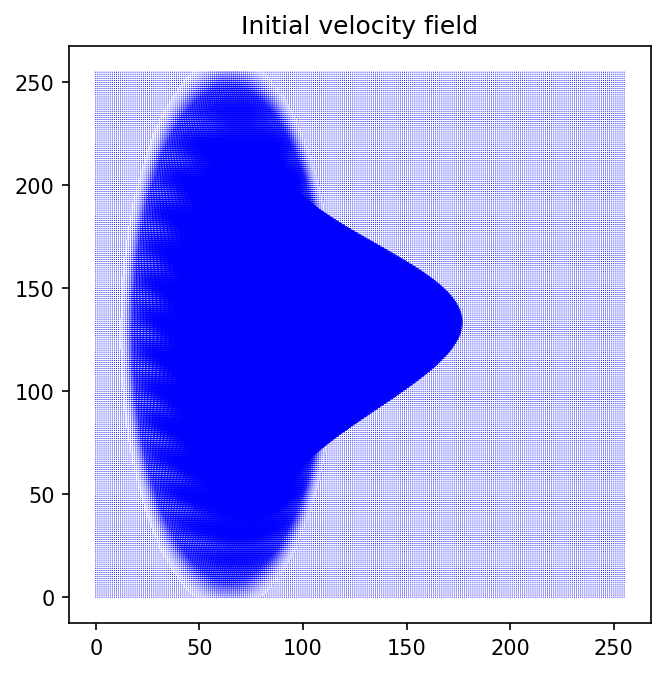

In [2]:
# Initial density + velocity: a blob drifting diagonally
N = 256
dt = 0.01
dx = 1 / N

x = torch.linspace(0, N - 1, N)
y = torch.linspace(0, N - 1, N)
X, Y = torch.meshgrid(x, y, indexing='ij')

rho0 = torch.exp(-((X - N // 4) ** 2 + 0.15 * (Y - N // 2) ** 2) / (2 * (N // 16) ** 2))
rho = rho0.clone()
ux0 = rho0.clone() * 20
ux = ux0.clone()
uy0 = rho0.clone() * 1
uy = uy0.clone()

fig = plt.figure(figsize=(5, 5))
plt.quiver(ux0.numpy().T, uy0.numpy().T, color='blue', scale=50, headlength=3, headaxislength=2, width=0.002)
plt.title('Initial velocity field')
fig.savefig(MEDIA_DIR / 'obstacle_initial_velocity.png', dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=MEDIA_DIR / 'obstacle_initial_velocity.png'))

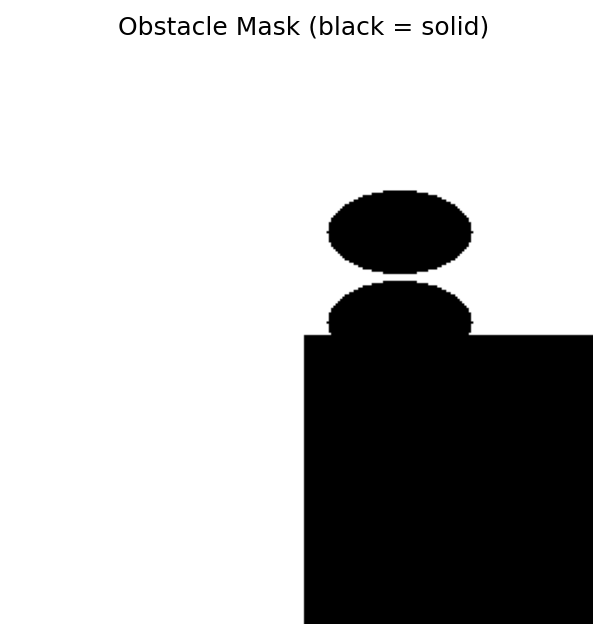

In [3]:
# Two vertically-offset elliptical obstacles with a rectangular notch removed
center = (N // 1.5, N // 2.5)
radius = N // 8

x_idx = torch.arange(N).view(-1, 1)
y_idx = torch.arange(N).view(1, -1)
mask = (
    ~((x_idx - center[0]) ** 2 + 3 * (y_idx - center[1] - 20) ** 2 <= radius ** 2)
    & ~((x_idx - center[0]) ** 2 + 3 * (y_idx - center[1] + 20) ** 2 <= radius ** 2)
)
mask[N // 2:, N // 2:] = False

fig = plt.figure(figsize=(5, 5))
plt.imshow(mask.numpy().T, cmap='gray')
plt.title('Obstacle Mask (black = solid)')
plt.axis('off')
fig.savefig(MEDIA_DIR / 'obstacle_mask.png', dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=MEDIA_DIR / 'obstacle_mask.png'))

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('white')
im = ax.imshow(rho.numpy().T, cmap='inferno', vmin=0, vmax=1, origin='lower', interpolation='bilinear')
ax.set_title('Density Field')
ax.contour(mask.numpy().T, levels=[0.5], colors='white', linewidths=1)
plt.colorbar(im, ax=ax, label='Density')

def update(frame):
    global rho, ux, uy, rho0, ux0, uy0
    if frame == 15:
        rho0, ux0, uy0 = fs.inject_source_gaussian(rho0, ux0, uy0, 40, 128, rho_0=1, ux_0=10)
    elif frame == 40:
        rho0, ux0, uy0 = fs.inject_source_gaussian(rho0, ux0, uy0, 150, 40, rho_0=1, ux_0=-2, uy_0=20)
    elif frame == 120:
        rho0, ux0, uy0 = fs.inject_source_gaussian(rho0, ux0, uy0, 64, 50, rho_0=0.5, ux_0=1, uy_0=4)
        rho0, ux0, uy0 = fs.inject_source_gaussian(rho0, ux0, uy0, 64, 70, rho_0=0.5, ux_0=-1, uy_0=-4)
    else:
        rho0, ux0, uy0 = rho.clone(), ux.clone(), uy.clone()
    ux, uy = fs.vel_step(ux, uy, ux0, uy0, dt, dx, 0, mask=mask)
    rho = fs.density_step(rho, ux, uy, rho0, 0.1, dt, mask=mask)
    im.set_array(rho.numpy().T)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=200, interval=50, blit=True)
ani.save(MEDIA_DIR / 'obstacle_fluid_sim.mp4', writer='ffmpeg', fps=20, dpi=80)
plt.close(fig)
print(f"Saved animation to {MEDIA_DIR / 'obstacle_fluid_sim.mp4'}")

Saved animation to media\obstacle_fluid_sim.mp4


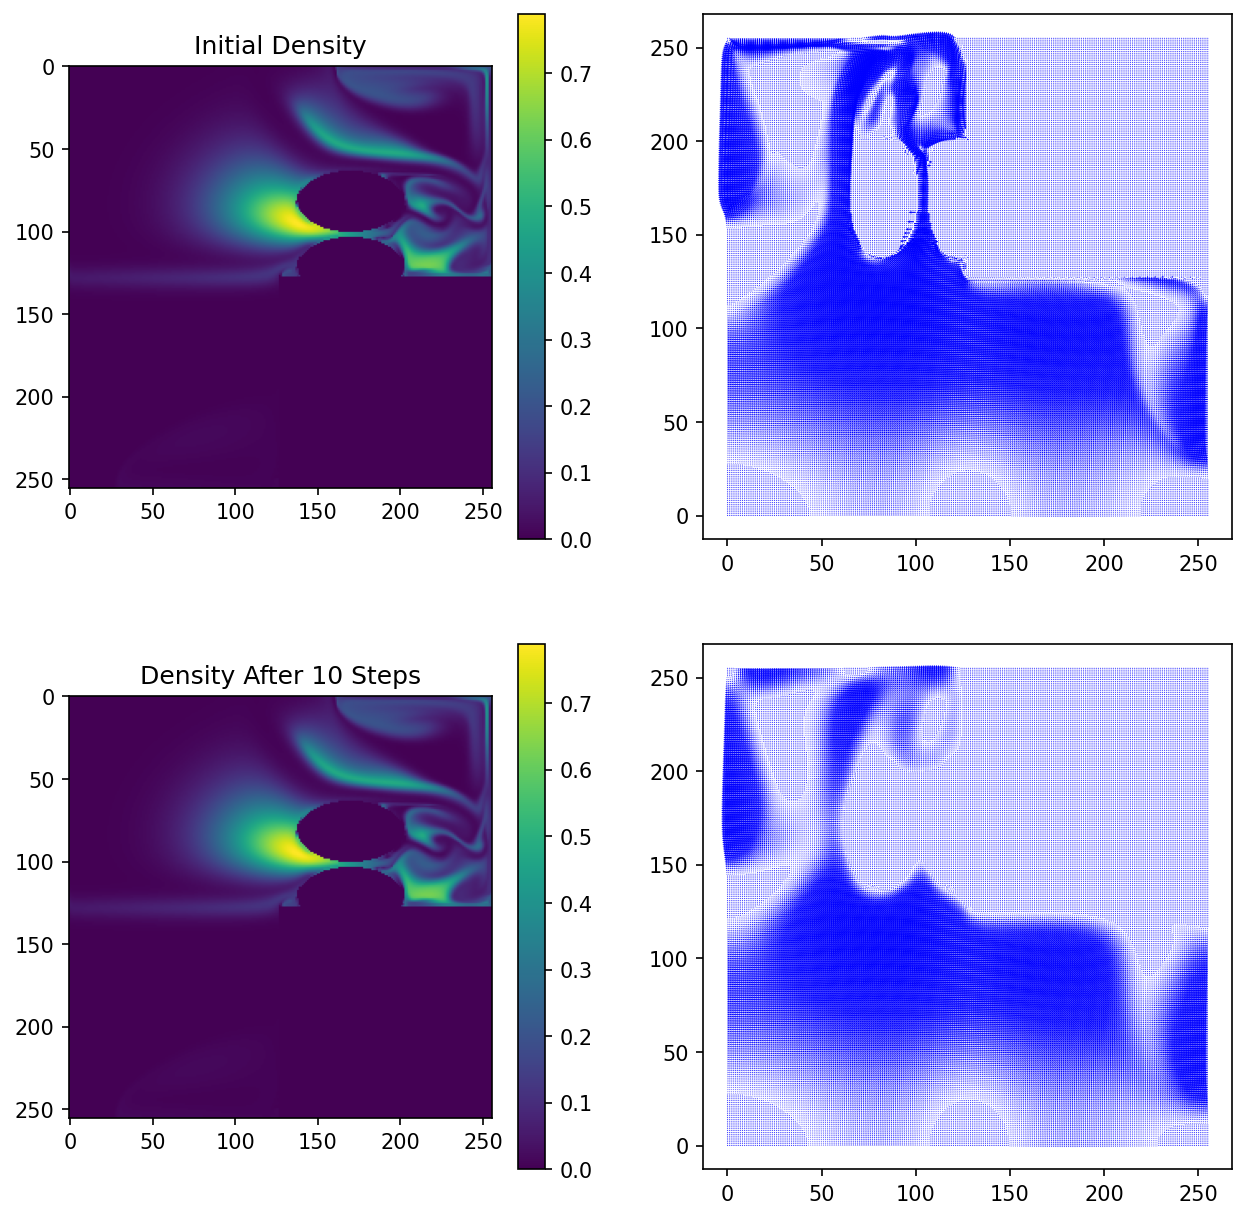

In [5]:
# Static before/after comparison, with viscosity
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(rho.numpy().T, cmap='viridis')
axes[0, 0].set_title('Initial Density')
axes[0, 1].quiver(ux0.numpy(), uy0.numpy(), color='blue', scale=50, headlength=3, headaxislength=2, width=0.002)

for i in range(10):
    ux, uy = fs.vel_step(ux, uy, ux0, uy0, dt, dx, 0.01, mask=mask)
    rho = fs.density_step(rho, ux, uy, rho0, 0.01, dt, mask=mask)

im = axes[1, 0].imshow(rho.numpy().T, cmap='viridis', vmin=0)
axes[1, 0].set_title('Density After 10 Steps')
axes[1, 1].quiver(ux.numpy(), uy.numpy(), color='blue', scale=50, headlength=3, headaxislength=2, width=0.002)
plt.colorbar(im, ax=axes[0, 0])
plt.colorbar(im, ax=axes[1, 0])
fig.savefig(MEDIA_DIR / 'obstacle_before_after.png', dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=MEDIA_DIR / 'obstacle_before_after.png'))